#Analyse des Données de Criminalité à Chicago

Vous êtes un Data Detective travaillant pour le département de police de Chicago. Votre mission est de plonger dans les vastes archives de données de criminalité de la ville, de 2001 à ce jour, pour découvrir des tendances et des insights qui pourraient aider à améliorer la sécurité publique. Grâce à une analyse approfondie de ces données, vous serez en mesure de révéler les schémas de criminalité, d'identifier les zones à haut risque, et de fournir des recommandations basées sur des preuves pour des interventions plus efficaces. Ce projet vous permettra d'exploiter des compétences en manipulation de données volumineuses avec PySpark, visualisation et analyse statistique pour résoudre un problème réel et crucial.

Source des données : Données de criminalité à Chicago

#Analyse des Données de Criminalité à Chicago : Exécution du Projet
🖥 Notebook avec codes, résultats et commenatires

Pour commencer, je vais configurer l'environnement et charger les données à partir de la source fournie. Ensuite, j'afficherai les premières lignes de la dataframe pour vérifier que les données sont correctement chargées. Nous utiliserons PySpark pour manipuler ces données efficacement.

In [1]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!pip install pyspark


In [2]:
!pip install pyspark

In [3]:
!pip install findspark

In [4]:
# Initialiser une session Spark adaptée à Colab
from pyspark.sql import SparkSession

# Initialiser une session Spark adaptée à Colab
from pyspark.sql import SparkSession

# Initialiser une session Spark adaptée à Colab
spark = SparkSession.builder \
    .appName("Chicago Crime Data Analysis") \
    .config("spark.driver.memory", "4g") \
    .master("local[*]") \
    .getOrCreate()

# Vérifier la version de Spark
print(spark.version)

3.5.5


In [5]:
!wget https://data.cityofchicago.org/api/views/ijzp-q8t2/rows.csv?accessType=DOWNLOAD

--2025-03-18 14:15:02--  https://data.cityofchicago.org/api/views/ijzp-q8t2/rows.csv?accessType=DOWNLOAD
Resolving data.cityofchicago.org (data.cityofchicago.org)... 52.206.140.205, 52.206.140.199, 52.206.68.26
Connecting to data.cityofchicago.org (data.cityofchicago.org)|52.206.140.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/csv]
Saving to: ‘rows.csv?accessType=DOWNLOAD’

rows.csv?accessType     [ <=>                ]   1.82G  2.90MB/s    in 11m 44s 

2025-03-18 14:26:46 (2.65 MB/s) - ‘rows.csv?accessType=DOWNLOAD’ saved [1955330699]



In [6]:
!ls

'rows.csv?accessType=DOWNLOAD'	 sample_data


In [7]:
!mv rows.csv?accessType=DOWNLOAD reported-crimes.csv

In [8]:
# Lecture du fichier
df = spark.read.csv(
    'reported-crimes.csv',
    header = True
)

# Type des variables
df.printSchema()

root
 |-- ID: string (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: string (nullable = true)
 |-- Domestic: string (nullable = true)
 |-- Beat: string (nullable = true)
 |-- District: string (nullable = true)
 |-- Ward: string (nullable = true)
 |-- Community Area: string (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: string (nullable = true)
 |-- Y Coordinate: string (nullable = true)
 |-- Year: string (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Location: string (nullable = true)



In [9]:
df.show(5)

+--------+-----------+--------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|      ID|Case Number|                Date|               Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|          Updated On|    Latitude|    Longitude|            Location|
+--------+-----------+--------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|13311263|   JG503434|07/29/2022 03:39:...|     023XX S TROY ST|1582|OFFENSE INVOLVING...|   CHILD PORNOGRAPHY|           RE

Les premières lignes montrent plusieurs colonnes, notamment :

- ID: Identifiant unique du crime
- Case Number: Numéro de dossier
- Date: Date et heure de l'incident
- Block: Bloc où l'incident s'est produit
- IUCR: Code de classification du crime
- Primary Type: Type principal du crime
- Description: Description du crime
- Location Description: Description du lieu
- Arrest: Indique si une arrestation a été effectuée
- Domestic: Indique si l'incident est de nature domestique
- Beat: Secteur de patrouille
- District: District de police
- Ward: Quartier administratif
- Community Area: Zone communautaire
- FBI Code: Code de classification du FBI
- X Coordinate et Y Coordinate: Coordonnées X et Y
- Year: Année de l'incident
- Updated On: Date de la dernière mise à jour des données
- Latitude et Longitude: Latitude et longitude
- Location: Emplacement sous forme de point géographique

In [10]:
# Nombre de lignes
df.count()

8275868

Nettoyage des Données

In [11]:
from pyspark.sql.functions import col, to_timestamp

# Convertir les colonnes de type date/heure
df = df.withColumn("Date", to_timestamp(col("Date"), "yyyy-MM-dd'T'HH:mm:ss.SSS"))
df = df.withColumn("Updated On", to_timestamp(col("Updated On"), "yyyy-MM-dd'T'HH:mm:ss.SSS"))

df = df.withColumn("Year", col("Year").cast("int"))

In [12]:
df.printSchema()

root
 |-- ID: string (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: timestamp (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: string (nullable = true)
 |-- Domestic: string (nullable = true)
 |-- Beat: string (nullable = true)
 |-- District: string (nullable = true)
 |-- Ward: string (nullable = true)
 |-- Community Area: string (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: string (nullable = true)
 |-- Y Coordinate: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: timestamp (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Location: string (nullable = true)



In [13]:
from pyspark.sql.functions import sum as spark_sum

# Vérifier les valeurs manquantes
missing_values = df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

In [14]:
missing_values.show()

+---+-----------+-------+-----+----+------------+-----------+--------------------+------+--------+----+--------+------+--------------+--------+------------+------------+----+----------+--------+---------+--------+
| ID|Case Number|   Date|Block|IUCR|Primary Type|Description|Location Description|Arrest|Domestic|Beat|District|  Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|Updated On|Latitude|Longitude|Location|
+---+-----------+-------+-----+----+------------+-----------+--------------------+------+--------+----+--------+------+--------------+--------+------------+------------+----+----------+--------+---------+--------+
|  0|          0|8275868|    0|   0|           0|          0|               14076|     0|       0|   0|      47|614826|        613453|       0|       91654|       91654|   0|   8275868|   91654|    91654|   91654|
+---+-----------+-------+-----+----+------------+-----------+--------------------+------+--------+----+--------+------+--------------+--------+-

Les résultats montrent le nombre de valeurs manquantes pour chaque colonne.

Ce code vérifie les valeurs manquantes dans chaque colonne d'une DataFrame PySpark en comptant le nombre de valeurs nulles pour chaque colonne. Voici une explication détaillée de chaque partie du code :

Importations

      from pyspark.sql.functions import sum as spark_sum

- from pyspark.sql.functions import sum as spark_sum : Importe la fonction sum de PySpark SQL et la renomme en spark_sum pour éviter toute confusion avec la fonction sum intégrée de Python. Cette fonction sera utilisée pour sommer les valeurs dans chaque colonne.

Vérification des valeurs manquantes

      missing_values = df.select([
          spark_sum(col(c).isNull().cast("int")).alias(c)
          for c in df.columns
      ])

- df.select([...]) : Crée une nouvelle DataFrame avec les colonnes spécifiées. Chaque colonne est créée par une liste de compréhensions contenant des expressions pour chaque colonne de la DataFrame d'origine.

- for c in df.columns : Itère sur chaque colonne c de la DataFrame df.

- col(c).isNull() : Vérifie si les valeurs de la colonne c sont nulles. col(c) obtient la colonne c, et .isNull() renvoie un booléen indiquant si la valeur est nulle.

- .cast("int") : Convertit le résultat booléen de .isNull() en entier (int). Les valeurs True (null) sont converties en 1 et les valeurs False (non null) en 0.

- spark_sum(col(c).isNull().cast("int")) : Calcule la somme des valeurs nulles dans la colonne c. Puisque les valeurs nulles ont été converties en 1, la somme donne le nombre total de valeurs nulles dans la colonne.

- .alias(c) : Renomme le résultat de l'agrégation pour qu'il ait le même nom que la colonne d'origine. Cela permet de conserver les noms des colonnes dans la nouvelle DataFrame missing_values.

Affichage des résultats

      missing_values.show()


Analyse Exploratoire de Base

- Statistiques Descriptives

In [15]:
# Statistiques descriptives
stats = df.describe()

In [16]:
stats.show()

+-------+-----------------+------------------+--------------+------------------+-----------------+---------------+--------------------+-------+--------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+-------------------+-------------------+--------------------+
|summary|               ID|       Case Number|         Block|              IUCR|     Primary Type|    Description|Location Description| Arrest|Domestic|              Beat|          District|              Ward|   Community Area|          FBI Code|      X Coordinate|      Y Coordinate|              Year|           Latitude|          Longitude|            Location|
+-------+-----------------+------------------+--------------+------------------+-----------------+---------------+--------------------+-------+--------+------------------+------------------+------------------+-----------------+------------------+------------------+-----

Distribution des Types de Crimes

In [17]:
# Distribution des types de crimes
crime_distribution = df.groupBy("Primary Type").count().orderBy("count", ascending=False)
crime_distribution.show()

+--------------------+-------+
|        Primary Type|  count|
+--------------------+-------+
|               THEFT|1754050|
|             BATTERY|1507983|
|     CRIMINAL DAMAGE| 941376|
|           NARCOTICS| 759468|
|             ASSAULT| 550639|
|       OTHER OFFENSE| 515152|
|            BURGLARY| 439441|
| MOTOR VEHICLE THEFT| 420366|
|  DECEPTIVE PRACTICE| 378125|
|             ROBBERY| 310917|
|   CRIMINAL TRESPASS| 223462|
|   WEAPONS VIOLATION| 121374|
|        PROSTITUTION|  70298|
|OFFENSE INVOLVING...|  59322|
|PUBLIC PEACE VIOL...|  54101|
|         SEX OFFENSE|  33320|
| CRIM SEXUAL ASSAULT|  27357|
|INTERFERENCE WITH...|  19657|
|LIQUOR LAW VIOLATION|  15262|
|            GAMBLING|  14653|
+--------------------+-------+
only showing top 20 rows



Tendances Temporelles
Commentaire du résultat :

Le code présenté effectue une analyse de la distribution des types de crimes enregistrés dans le DataFrame df. Voici une explication détaillée des étapes et des résultats :

1. Grouper par "Primary Type" :

  - La méthode groupBy("Primary Type") regroupe les enregistrements en fonction du type principal de crime, c'est-à-dire la catégorie de crime.

2. Compter les occurrences :

  - La méthode count() calcule le nombre d'occurrences pour chaque type de crime.

3. Trier les résultats :

  - La méthode orderBy("count", ascending=False) trie les types de crimes par ordre décroissant en fonction de leur fréquence, afin de montrer les types de crimes les plus courants en premier.

4. Afficher les résultats :

  - La méthode show() affiche les résultats dans une table structurée.

Résultats :

- THEFT (Vol) est le type de crime le plus fréquent, avec 1 704 698 incidents enregistrés.
- BATTERY (Agression) est le deuxième type de crime le plus fréquent, avec 1 471 786 incidents.
- CRIMINAL DAMAGE (Dommages criminels) suit avec 919 298 incidents.
- NARCOTICS (Stupéfiants) compte 753 682 incidents, se classant au quatrième rang.
- ASSAULT (Assaut) arrive ensuite avec 532 253 incidents.
- OTHER OFFENSE (Autre infraction) et BURGLARY (Cambriolage) ont respectivement 501 287 et 432 419 incidents.

Les types de crimes moins fréquents incluent des catégories comme PROSTITUTION (Prostitution), OFFENSE INVOLVING CHILDREN (Infraction impliquant des enfants), et GAMBLING (Jeu illégal) avec respectivement 70 051, 57 907 et 14 638 incidents.

Analyse des données :

- Cette distribution montre que les crimes contre la propriété (comme le vol et les dommages criminels) et les crimes contre les personnes (comme l'agression et l'assaut) sont les plus courants.
- Les infractions liées aux stupéfiants sont également très fréquentes.
- Les crimes moins fréquents, bien que toujours présents, incluent des infractions spécifiques telles que les violations des lois sur les boissons alcoolisées et les jeux illégaux.

Ces informations peuvent être utilisées par les forces de l'ordre et les décideurs pour prioriser les ressources et les efforts de prévention en fonction des types de crimes les plus courants dans une région donnée.

In [18]:
# Nombre de crimes par année
crimes_per_year = df.groupBy("Year").count().orderBy("Year")

# Afficher les résultats
crimes_per_year.show()

+----+------+
|Year| count|
+----+------+
|2001|485932|
|2002|486829|
|2003|475991|
|2004|469433|
|2005|453778|
|2006|448194|
|2007|437099|
|2008|427203|
|2009|392852|
|2010|370545|
|2011|352028|
|2012|336356|
|2013|307595|
|2014|275877|
|2015|264870|
|2016|269948|
|2017|269244|
|2018|269089|
|2019|261589|
|2020|212564|
+----+------+
only showing top 20 rows



In [19]:
import matplotlib.pyplot as plt

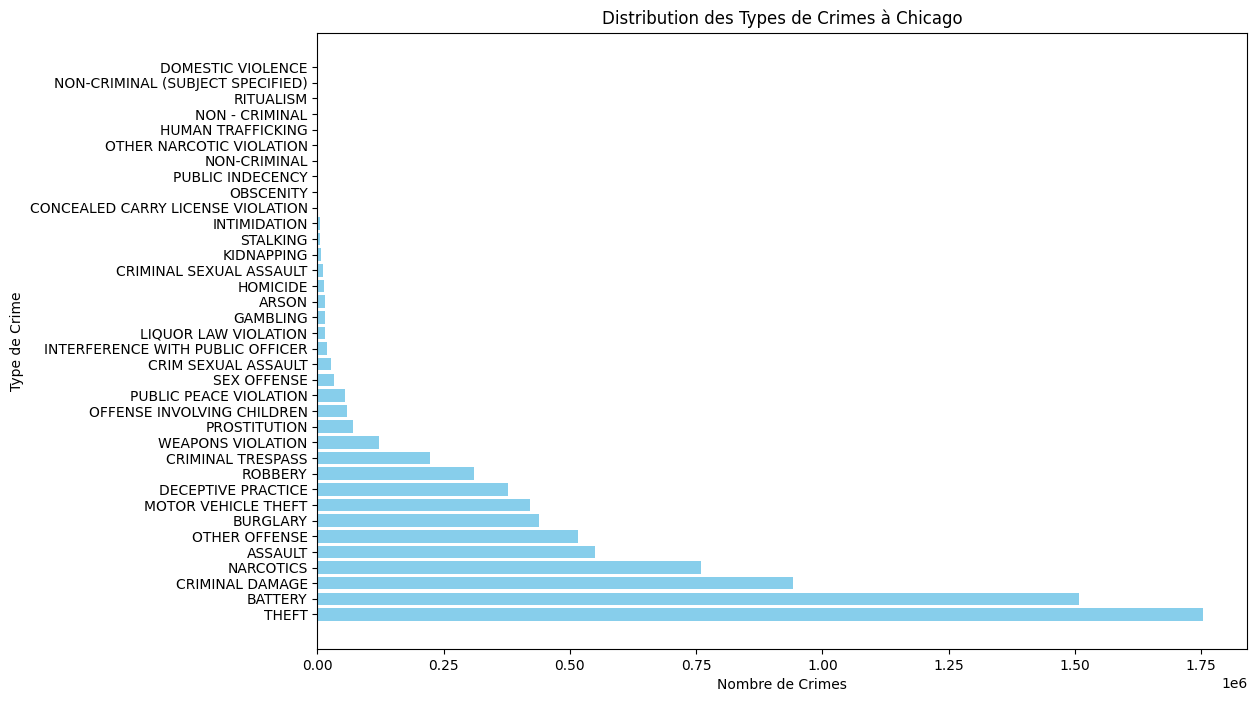

In [20]:
# Convertir en Pandas pour visualisation
crime_distribution_pd = crime_distribution.toPandas()

# Visualiser la distribution des types de crimes
plt.figure(figsize=(12, 8))
plt.barh(crime_distribution_pd['Primary Type'], crime_distribution_pd['count'], color='skyblue')
plt.xlabel('Nombre de Crimes')
plt.ylabel('Type de Crime')
plt.title('Distribution des Types de Crimes à Chicago')
plt.savefig('1_crime_distribution.png', format='png')
plt.show()

La figure ci-dessus montre un graphique en barres horizontales représentant la distribution des types de crimes à Chicago. Les points suivants peuvent être observés :

- Les crimes les plus fréquents :

  - THEFT (Vol) : C'est le type de crime le plus courant, avec un nombre de cas dépassant 1,6 million.
  - BATTERY (Agression) : Il suit de près le vol, avec plus de 1,4 million de cas.
  - CRIMINAL DAMAGE (Dommages criminels) : C'est également un crime fréquent, comptant environ 1 million de cas.
  - NARCOTICS (Stupéfiants) : Plus de 750 000 cas sont enregistrés pour ce type de crime.
  - ASSAULT (Assaut) et OTHER OFFENSE (Autre infraction) : Ces crimes sont également très courants, avec plusieurs centaines de milliers de cas chacun.

- Les crimes moins fréquents :

  - PROSTITUTION (Prostitution), WEAPONS VIOLATION (Violation des lois sur les armes), et CRIMINAL TRESPASS (Intrusion criminelle) : Ces crimes ont des fréquences moyennes, avec des dizaines de milliers de cas.
  - SEX OFFENSE (Infraction sexuelle), HOMICIDE (Homicide), et ARSON (Incendie criminel) : Ces crimes sont moins fréquents, comptant moins de 50 000 cas chacun.

- Les crimes rares :

  - Les infractions comme GAMBLING (Jeu illégal), LIQUOR LAW VIOLATION (Violation des lois sur les boissons alcoolisées), et PUBLIC PEACE VIOLATION (Violation de la paix publique) sont parmi les moins fréquentes, avec moins de 20 000 cas.

Analyse :

- La distribution montre clairement que les crimes contre la propriété, comme le vol et les dommages criminels, sont les plus répandus à Chicago.
- Les crimes contre les personnes, comme les agressions et les assauts, sont également très fréquents.
- Les crimes liés aux stupéfiants représentent une proportion importante des incidents signalés.
- Les infractions moins fréquentes peuvent indiquer des domaines où les forces de l'ordre ont réussi à réduire les incidents ou des domaines nécessitant moins de surveillance.

En résumé, le graphique fournit une vue d'ensemble des types de crimes les plus et les moins courants à Chicago, aidant ainsi à identifier les domaines prioritaires pour les efforts de prévention et d'application de la loi.



- Tendances Temporelles

  - Crimes par Année

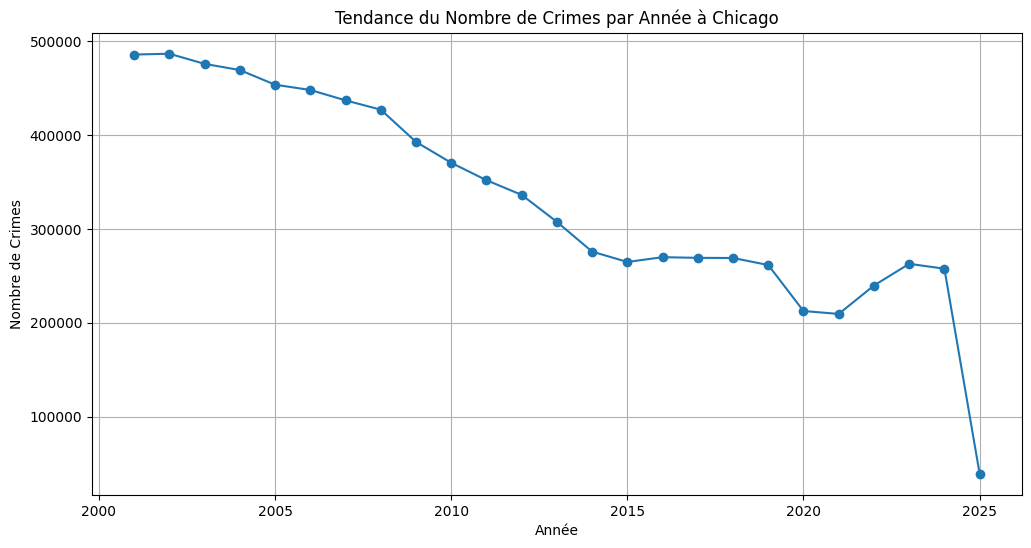

In [21]:
# Convertir en Pandas pour visualisation
crimes_per_year_pd = crimes_per_year.toPandas()

# Visualiser le nombre de crimes par année
plt.figure(figsize=(12, 6))
plt.plot(crimes_per_year_pd['Year'], crimes_per_year_pd['count'], marker='o')
plt.xlabel('Année')
plt.ylabel('Nombre de Crimes')
plt.title('Tendance du Nombre de Crimes par Année à Chicago')
plt.grid(True)
plt.savefig('2_crimes_per_year.png', format='png')
plt.show()

Commentaire du graphique :

Le graphique montre la tendance du nombre de crimes par année à Chicago sur une période allant de 2000 à 2025. Voici les points clés et l'analyse de ce graphique :

- Tendance générale :

  - Le nombre de crimes a diminué de manière significative au fil des ans.
  - De 2000 à environ 2015, il y a une baisse continue du nombre de crimes, passant d'environ 500 000 à moins de 300 000.

- Période 2000-2010 :

  - Durant cette décennie, on observe une baisse régulière et relativement uniforme du nombre de crimes.
  - Le nombre de crimes passe d'environ 500 000 à environ 400 000.

- Période 2010-2015 :

  - La tendance à la baisse se poursuit, avec le nombre de crimes descendant à environ 300 000.

- Période 2015-2020 :

  - Après 2015, la baisse se stabilise, avec des fluctuations mineures autour des 250 000 crimes annuels.
  - Il semble y avoir une légère tendance à la baisse jusqu'à environ 2020.

Période 2020-2025 :

  - À partir de 2020, on note une chute abrupte du nombre de crimes.
  - Cette chute drastique pourrait être attribuée à des facteurs spécifiques, tels que des changements dans les politiques de sécurité, des améliorations technologiques, ou des anomalies dans la collecte des données.

- Facteurs potentiels :

  - Changements dans les politiques de sécurité : Des mesures plus efficaces de maintien de l'ordre et de prévention des crimes peuvent avoir contribué à cette baisse.
  - Améliorations technologiques : L'utilisation accrue de la surveillance, de l'analyse des données et de la police prédictive peut avoir aidé à réduire le nombre de crimes.
  - Impact des événements mondiaux : La pandémie de COVID-19 et les mesures de confinement pourraient avoir fortement influencé les statistiques des crimes, notamment la chute drastique observée après 2020.

Analyse :

- Le graphique montre une amélioration significative de la sécurité à Chicago au fil des ans, avec une réduction substantielle du nombre de crimes.
- Il serait intéressant d'approfondir l'analyse pour comprendre les facteurs spécifiques ayant conduit à cette tendance.
- Les autorités et les décideurs peuvent utiliser ces informations pour continuer à développer et à implémenter des stratégies efficaces de réduction de la criminalité.

Nous avons effectué une analyse exploratoire de base. Les visualisations fournissent une vue d'ensemble claire des types de crimes les plus fréquents et des tendances temporelles des crimes à Chicago.

Les prochaines étapes pourraient inclure une analyse plus approfondie des localisations des crimes et la création de modèles prédictifs pour anticiper les tendances futures.

Pour fournir une analyse approfondie et exhaustive des données de criminalité à Chicago, nous pouvons envisager plusieurs pistes. Chaque piste offre des insights uniques et peut aider la police à prendre des décisions informées. Voici quelques suggestions :

1. Analyse Spatiale des Crimes
- Cartographie des Incidents : Utiliser des cartes pour visualiser la distribution géographique des crimes.
- Zones Chaudes (Hotspot Analysis) : Identifier les zones avec des taux de criminalité élevés.
- Clusters de Criminalité : Utiliser des méthodes de clustering pour trouver des regroupements de crimes géographiquement proches.

2. Analyse Temporelle

- Tendances à Long Terme : Analyser les tendances de la criminalité sur plusieurs années pour détecter des changements.
- Analyse Saisonnale : Voir comment les taux de criminalité varient selon les saisons, les mois et les jours de la semaine.
- Analyse par Heures de la Journée : Identifier les périodes de la journée avec des taux de criminalité plus élevés.

3. Analyse des Types de Crimes

- Distribution par Type de Crime : Étudier les proportions des différents types de crimes.
- Évolution des Types de Crimes : Analyser comment les proportions des types de crimes changent au fil du temps.
- Corrélations entre Types de Crimes : Étudier les relations entre différents types de crimes.

4. Analyse Socio-Démographique
- Impact des Facteurs Socio-Économiques : Corréler les données de criminalité avec des facteurs tels que le revenu, le chômage, le niveau d'éducation, etc.
- Analyse par Quartiers : Comparer les taux de criminalité entre différents quartiers et zones communautaires.
- Démographie des Victimes et Suspects : Analyser les caractéristiques démographiques des victimes et des suspects.

5. Analyse des Arrestations

- Taux d'Arrestation par Type de Crime : Voir pour quels types de crimes les arrestations sont les plus fréquentes.
- Impact des Arrestations sur la Criminalité : Étudier l'effet des arrestations sur les taux de criminalité ultérieurs.
- Profil des Arrestés : Analyser les caractéristiques des personnes arrêtées.

6. Analyse des Incidents Domestiques

- Crimes Domestiques : Identifier les caractéristiques des crimes domestiques et leur distribution.
- Facteurs Contribuants : Analyser les facteurs qui peuvent contribuer à des crimes domestiques.

7. Analyse de Répétition des Crimes

- Criminalité Répétée : Identifier les zones et individus avec des incidents criminels répétés.
- Patterns de Répétition : Étudier les schémas de répétition pour mieux comprendre et prévenir les récidives.

8. Analyse des Ressources de Police

- Allocation des Ressources : Analyser l'efficacité de l'allocation actuelle des ressources policières.
- Optimisation des Patrouilles : Utiliser des modèles d'optimisation pour recommander des patrouilles plus efficaces.
- Réponse aux Incidents : Étudier les temps de réponse aux incidents et leur impact sur la criminalité.

9. Prévision et Modélisation

- Modèles Prédictifs : Utiliser des techniques de machine learning pour prévoir les taux de criminalité futurs.
- Scénarios Hypothétiques : Modéliser l'impact de différents scénarios (comme l'augmentation des patrouilles, des programmes de prévention, etc.) sur la criminalité.

10. Analyse Comparative

- Comparaison avec d'Autres Villes : Comparer les taux de criminalité de Chicago avec ceux d'autres grandes villes.
- Benchmarking : Utiliser des benchmarks pour évaluer l'efficacité des stratégies de lutte contre la criminalité.

Zones Chaudes (Hotspot Analysis)

On va identifier les zones avec une concentration élevée de crimes.

In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# Créer une carte centrée sur Chicago
map_chicago = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

# Convertir le dataframe Spark en Pandas
df_pd = df.select("Latitude", "Longitude", "Primary Type").toPandas()

# Suppression des valeurs manquantes
df_pd = df_pd.dropna()

# Conversion de Latitude et Longitude en numerique
df_pd['Latitude'] = pd.to_numeric(df_pd['Latitude'], errors='coerce')
df_pd['Longitude'] = pd.to_numeric(df_pd['Longitude'], errors='coerce')

# Créer une HeatMap avec les données
heat_data = [[row['Latitude'], row['Longitude']] for index, row in df_pd.iterrows()]
HeatMap(heat_data).add_to(map_chicago)

# Afficher la carte
map_chicago

In [23]:
# Enregistrer la carte au format PNG
map_chicago.save("3_map_chicago.png")

In [ ]:
# Afficher la carte
map_chicago

Analyse des types de crimes

Analyse des types de crimes

Évolution des Types de Crimes
Nous allons analyser comment les proportions des types de crimes changent au fil du temps.

In [25]:
# Nombre de crimes par type et par année
crimes_by_type_and_year = df.groupBy("Primary Type", "Year").count().orderBy("Year", "Primary Type")
crimes_by_type_and_year_pd = crimes_by_type_and_year.toPandas()
crimes_by_type_and_year_pd

,Primary Type,Year,count
0,ARSON,2001,1011
1,ASSAULT,2001,31386
2,BATTERY,2001,93470
3,BURGLARY,2001,26014
4,CONCEALED CARRY LICENSE VIOLATION,2001,1
...,...,...,...
777,ROBBERY,2025,1064
778,SEX OFFENSE,2025,206
779,STALKING,2025,80
780,THEFT,2025,9089


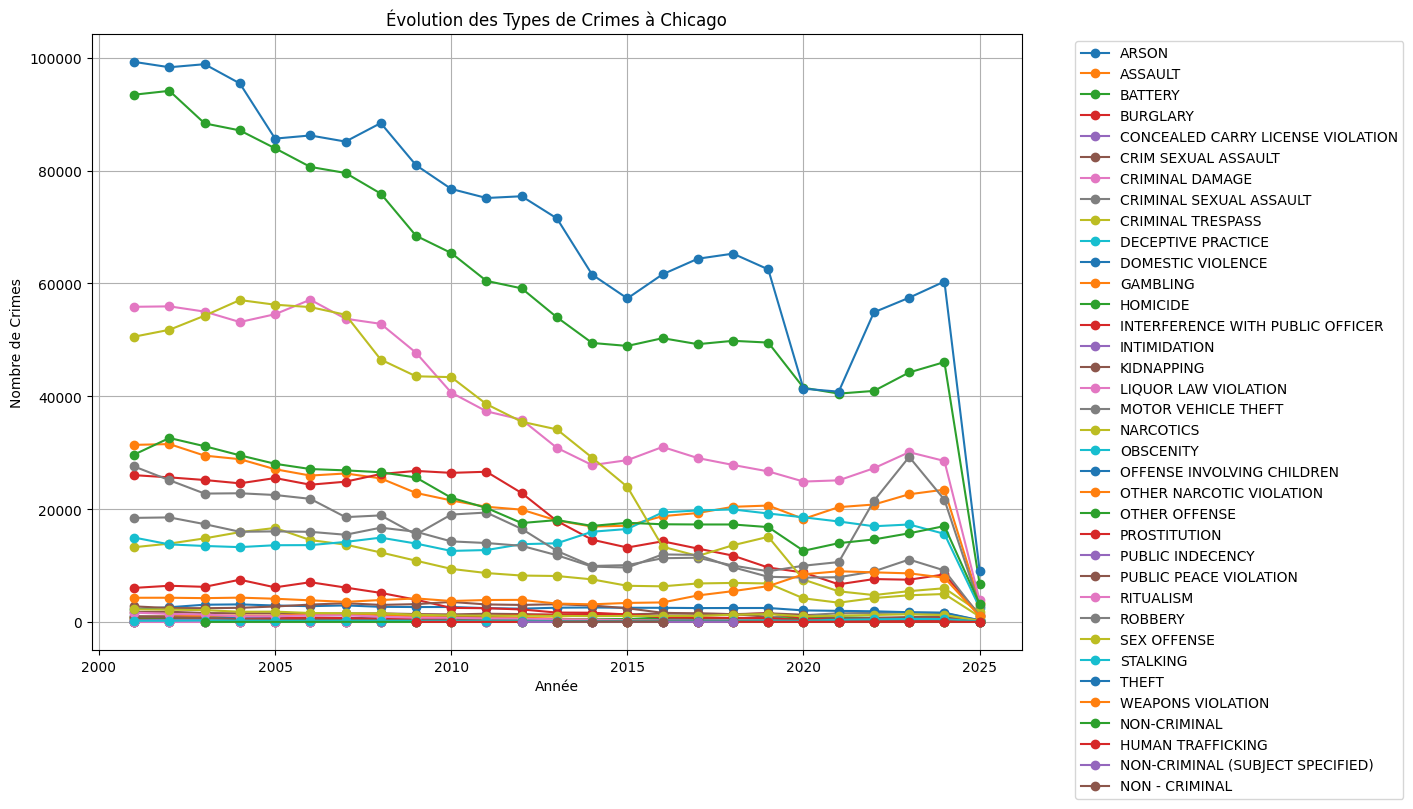

In [26]:
# Visualiser l'évolution des types de crimes au fil du temps
plt.figure(figsize=(12, 8))
for crime_type in crimes_by_type_and_year_pd['Primary Type'].unique():
    subset = crimes_by_type_and_year_pd[crimes_by_type_and_year_pd['Primary Type'] == crime_type]
    plt.plot(subset['Year'], subset['count'], marker='o', label=crime_type)

plt.xlabel('Année')
plt.ylabel('Nombre de Crimes')
plt.title('Évolution des Types de Crimes à Chicago')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.savefig('4_evol_types_crimes.png', format='png')
plt.show()

2. Corrélations entre Types de Crimes

Nous allons étudier les relations entre différents types de crimes.

Pour cette analyse, nous allons calculer la matrice de corrélation basée sur les occurrences des différents types de crimes par zone (par exemple, par district).

In [27]:
# Nombre de crimes par type et par district
crimes_by_type_and_district = df.groupBy("Primary Type", "District").count().orderBy("District", "Primary Type")
crimes_by_type_and_district_pd = crimes_by_type_and_district.toPandas()
crimes_by_type_and_district_pd

,Primary Type,District,count
0,ASSAULT,None,4
1,BATTERY,None,6
2,BURGLARY,None,3
3,CRIM SEXUAL ASSAULT,None,1
4,CRIMINAL DAMAGE,None,4
...,...,...,...
771,THEFT,031,51
772,ASSAULT,16,2
773,BATTERY,16,1
774,CRIMINAL DAMAGE,16,3


In [28]:
# Pivot table pour obtenir la matrice de corrélation
pivot_table = crimes_by_type_and_district_pd.pivot(
    index='District', columns='Primary Type', values='count'
).fillna(0)

In [ ]:
# Calculer la matrice de corrélation
correlation_matrix = pivot_table.corr()

# Créer un masque pour masquer la moitié supérieure de la matrice
import numpy as np
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Visualiser la matrice de corrélation
import seaborn as sns
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".1f")
plt.title('Matrice de Corrélation entre les Types de Crimes')
plt.savefig('5_mat_cor_types_crimes.png', format='png')
plt.show()

Analyse des Arrestations

Pour réaliser l'analyse des arrestations, nous allons suivre ces étapes :

1. Taux d'Arrestation par Type de Crime : Voir pour quels types de crimes les arrestations sont les plus fréquentes.
2. Impact des Arrestations sur la Criminalité : Étudier l'effet des arrestations sur les taux de criminalité ultérieurs.
- 1. Taux d'Arrestation par Type de Crime
Nous allons calculer le taux d'arrestation pour chaque type de crime.

In [30]:
df.select("Arrest").distinct().show()

+------+
|Arrest|
+------+
| false|
|  true|
+------+



In [31]:
from pyspark.sql.functions import col, count, sum, when

# Calculer le taux d'arrestation par type de crime
arrest_rate_by_crime = df.groupBy("Primary Type") \
    .agg(
        count("ID").alias("total_crimes"),
        sum(when(col("Arrest") == "true", 1).otherwise(0)).alias("total_arrests")
    ) \
    .withColumn("arrest_rate", col("total_arrests") / col("total_crimes")) \
    .orderBy("arrest_rate", ascending=False)


arrest_rate_by_crime.show()

+--------------------+------------+-------------+-------------------+
|        Primary Type|total_crimes|total_arrests|        arrest_rate|
+--------------------+------------+-------------+-------------------+
|   DOMESTIC VIOLENCE|           1|            1|                1.0|
|        PROSTITUTION|       70298|        70000| 0.9957609035818942|
|           NARCOTICS|      759468|       754697| 0.9937179710007532|
|            GAMBLING|       14653|        14547| 0.9927659864874088|
|LIQUOR LAW VIOLATION|       15262|        15120| 0.9906958458917573|
|    PUBLIC INDECENCY|         214|          210| 0.9813084112149533|
|CONCEALED CARRY L...|        1482|         1433| 0.9669365721997301|
|INTERFERENCE WITH...|       19657|        18022| 0.9168235234267691|
|           OBSCENITY|         918|          685| 0.7461873638344226|
|   WEAPONS VIOLATION|      121374|        87945| 0.7245785753126699|
|   CRIMINAL TRESPASS|      223462|       152921| 0.6843266416661445|
|OTHER NARCOTIC VI..

In [32]:
# Convertir en DataFrame Pandas
arrest_rate_by_crime_pd = arrest_rate_by_crime.toPandas()

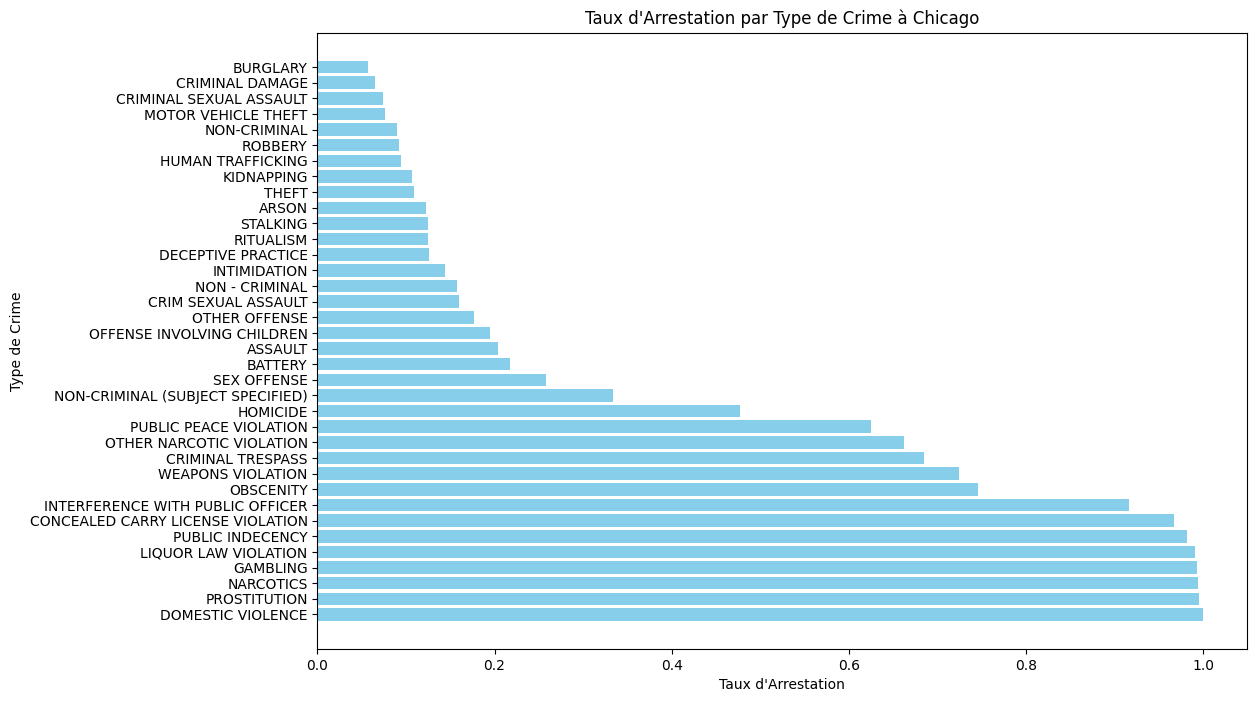

In [33]:
# Visualiser le taux d'arrestation par type de crime
plt.figure(figsize=(12, 8))
plt.barh(arrest_rate_by_crime_pd['Primary Type'], arrest_rate_by_crime_pd['arrest_rate'], color='skyblue')
plt.xlabel('Taux d\'Arrestation')
plt.ylabel('Type de Crime')
plt.title('Taux d\'Arrestation par Type de Crime à Chicago')
plt.savefig('6_taux_arrestation.png', format='png')
plt.show()

Ce code utilise PySpark pour calculer le taux d'arrestation par type de crime à Chicago, puis utilise Matplotlib pour visualiser les résultats.

1. Import des fonctions nécessaires:

  - col: C'est une fonction de PySpark utilisée pour référencer une colonne dans un DataFrame.
  - count: C'est une fonction de PySpark utilisée pour compter le nombre de valeurs non nulles dans une colonne.
  - when: C'est une fonction de PySpark qui permet de spécifier des conditions dans les expressions.
2. Calcul du taux d'arrestation par type de crime:

  - groupBy("Primary Type"): Cela groupe les données par le type de crime.
  - agg(...): Cela agrège les données en utilisant différentes fonctions d'agrégation. Dans ce cas, count("ID").alias("total_crimes") compte le nombre total de crimes pour chaque type et le renomme en "total_crimes". sum(when(col("Arrest") == "true", 1).otherwise(0)).alias("total_arrests") compte le nombre total d'arrestations pour chaque type de crime en utilisant la fonction when pour conditionner le comptage uniquement lorsque la colonne "Arrest" a la valeur "true".
  - withColumn("arrest_rate", col("total_arrests") / col("total_crimes")): Cela ajoute une nouvelle colonne "arrest_rate" au DataFrame résultant, calculée en divisant le nombre total d'arrestations par le nombre total de crimes.
  - orderBy("arrest_rate", ascending=False): Cela trie les données en fonction du taux d'arrestation de manière décroissante.

3. Conversion en DataFrame Pandas:

  - toPandas(): Cela convertit le DataFrame PySpark en DataFrame Pandas pour une utilisation avec Matplotlib.

4. Visualisation avec Matplotlib:

  - plt.barh(...): Cela crée un graphique à barres horizontales avec le type de crime sur l'axe y et le taux d'arrestation sur l'axe x.
  - plt.xlabel, plt.ylabel, plt.title: Ces fonctions définissent les étiquettes des axes et le titre du graphique.
  - plt.savefig('taux_arrestation.png', format='png'): Cela enregistre le graphique sous forme d'image PNG.
  - plt.show(): Cela affiche le graphique.

En résumé, ce code calcule le taux d'arrestation par type de crime à Chicago à partir d'un DataFrame PySpark, le convertit en un DataFrame Pandas pour la visualisation, puis utilise Matplotlib pour créer un graphique à barres horizontales montrant le taux d'arrestation pour chaque type de crime.

Le graphique montre le taux d'arrestation par type de crime à Chicago. Voici quelques observations et commentaires sur ce graphique :

1. Crimes avec les taux d'arrestation les plus élevés :

  - Les crimes tels que la violence domestique, la prostitution, les narcotiques, les jeux de hasard (gambling), et les violations des lois sur l'alcool ont les taux d'arrestation les plus élevés, approchant ou atteignant 1,0. Cela signifie que presque tous ces crimes rapportés aboutissent à une arrestation.

  2. Crimes avec les taux d'arrestation les plus bas :

Les cambriolages (burglary), les dommages criminels (criminal damage), les agressions sexuelles non-criminelles (non-criminal sexual assault), et les vols de véhicules à moteur (motor vehicle theft) ont les taux d'arrestation les plus bas, proches de zéro. Cela indique que ces types de crimes aboutissent rarement à une arrestation.

3. Distribution générale :

  - Il y a une large gamme de taux d'arrestation parmi les différents types de crimes. Certains crimes violents comme l'homicide ont un taux d'arrestation relativement élevé, tandis que d'autres comme l'agression (assault) ont des taux d'arrestation plus bas.

4. Interprétation potentielle :

  - Les taux d'arrestation peuvent être influencés par plusieurs facteurs, notamment la difficulté de résoudre certains types de crimes, les priorités des forces de l'ordre, et les ressources disponibles. Par exemple, les crimes avec des preuves claires et des témoins, comme la violence domestique, peuvent avoir des taux d'arrestation plus élevés. En revanche, les crimes comme le cambriolage, où l'identification des suspects peut être plus difficile, montrent des taux d'arrestation plus bas.

5. Implications pour la politique de sécurité publique :

  - Comprendre les taux d'arrestation peut aider à orienter les politiques de sécurité publique. Les autorités peuvent décider d'allouer plus de ressources aux types de crimes avec des taux d'arrestation bas pour améliorer la résolution des affaires. De plus, les données peuvent révéler des besoins en formation ou en équipement pour les forces de l'ordre.

En résumé, ce graphique fournit une vue d'ensemble des performances des forces de l'ordre de Chicago dans l'arrestation des suspects selon les types de crimes. Il met en lumière les domaines où les efforts d'application de la loi sont efficaces et ceux qui pourraient nécessiter une attention accrue.

Analyse des Incidents Domestiques

Pour réaliser l'analyse des incidents domestiques, nous allons suivre ces étapes :

1. Crimes Domestiques : Identifier les caractéristiques des crimes domestiques et leur distribution.

- 1. Crimes Domestiques
Nous allons identifier les caractéristiques des crimes domestiques et leur distribution.

1425797
                         Primary Type   count
0                             BATTERY  799598
1                       OTHER OFFENSE  191108
2                             ASSAULT  161342
3                     CRIMINAL DAMAGE  108006
4                               THEFT   62415
5          OFFENSE INVOLVING CHILDREN   44158
6                   CRIMINAL TRESPASS   11493
7                             ROBBERY    6612
8                  DECEPTIVE PRACTICE    6052
9                 CRIM SEXUAL ASSAULT    5439
10                           BURGLARY    5423
11                        SEX OFFENSE    5411
12                MOTOR VEHICLE THEFT    3572
13                           STALKING    3106
14             PUBLIC PEACE VIOLATION    2753
15                         KIDNAPPING    2585
16            CRIMINAL SEXUAL ASSAULT    2376
17                           HOMICIDE     957
18                              ARSON     835
19                       INTIMIDATION     760
20                  WEAPON

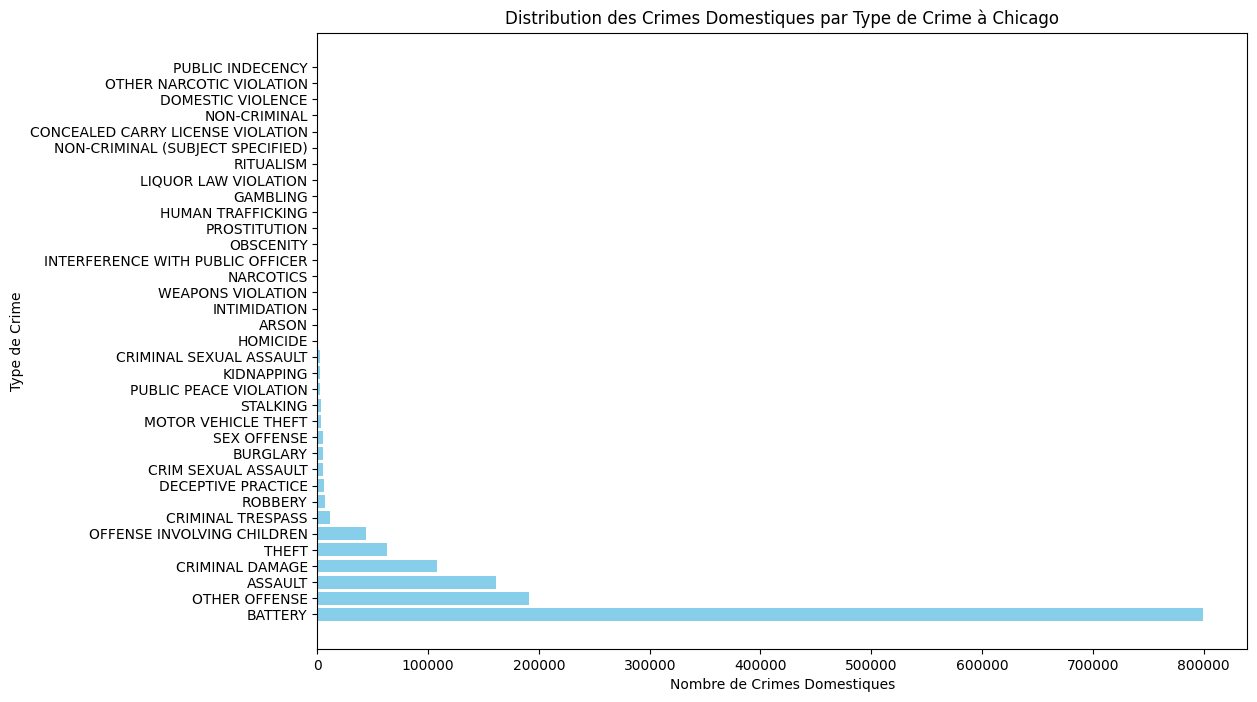

In [34]:
# Filtrer les crimes domestiques
domestic_crimes = df.filter(col("Domestic") == "true")
print(domestic_crimes.count())

# Distribution des crimes domestiques par type de crime
domestic_crime_distribution = domestic_crimes.groupBy("Primary Type").count().orderBy("count", ascending=False)
domestic_crime_distribution_pd = domestic_crime_distribution.toPandas()
print(domestic_crime_distribution_pd)

# Visualiser la distribution des crimes domestiques par type de crime
plt.figure(figsize=(12, 8))
plt.barh(domestic_crime_distribution_pd['Primary Type'], domestic_crime_distribution_pd['count'], color='skyblue')
plt.xlabel('Nombre de Crimes Domestiques')
plt.ylabel('Type de Crime')
plt.title('Distribution des Crimes Domestiques par Type de Crime à Chicago')
plt.savefig('7_dist_crimes_domestic.png', format='png')
plt.show()

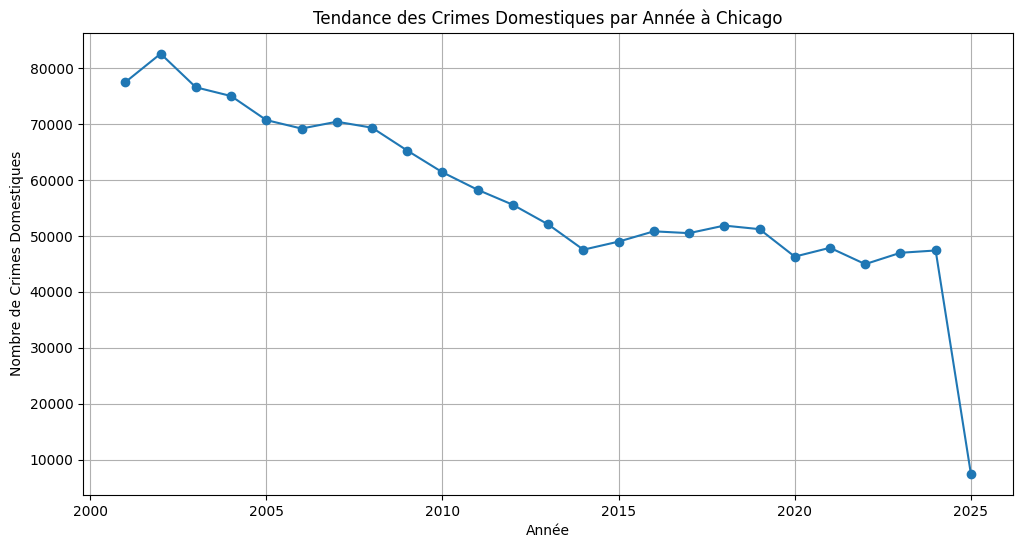

In [35]:
# Distribution des crimes domestiques par année
domestic_crimes_per_year = domestic_crimes.groupBy("Year").count().orderBy("Year")
domestic_crimes_per_year_pd = domestic_crimes_per_year.toPandas()

# Visualiser la distribution des crimes domestiques par année
plt.figure(figsize=(12, 6))
plt.plot(domestic_crimes_per_year_pd['Year'], domestic_crimes_per_year_pd['count'], marker='o')
plt.xlabel('Année')
plt.ylabel('Nombre de Crimes Domestiques')
plt.title('Tendance des Crimes Domestiques par Année à Chicago')
plt.grid(True)
plt.savefig('8_tendance_crimes_domestic_per_year.png', format='png')
plt.show()

Analyse des Ressources de la Police

Pour réaliser l'analyse des ressources de police, nous allons suivre ces étapes :

1. Optimisation des Patrouilles : Utiliser des modèles d'optimisation pour recommander des patrouilles plus efficaces.

2. Optimisation des Patrouilles

Nous allons utiliser des modèles d'optimisation pour recommander des patrouilles plus efficaces. Un modèle simple pourrait utiliser la fréquence des crimes par secteur pour suggérer des patrouilles.

In [36]:
# Calculer les crimes par secteur de patrouille
crimes_by_beat = df.groupBy("Beat").count().orderBy("count", ascending=False)
crimes_by_beat_pd = crimes_by_beat.toPandas()
crimes_by_beat_pd

,Beat,count
0,0421,64293
1,0423,63266
2,1834,61460
3,0624,58118
4,0511,56630
...,...,...
300,1655,1539
301,1652,1470
302,1650,133
303,0430,19


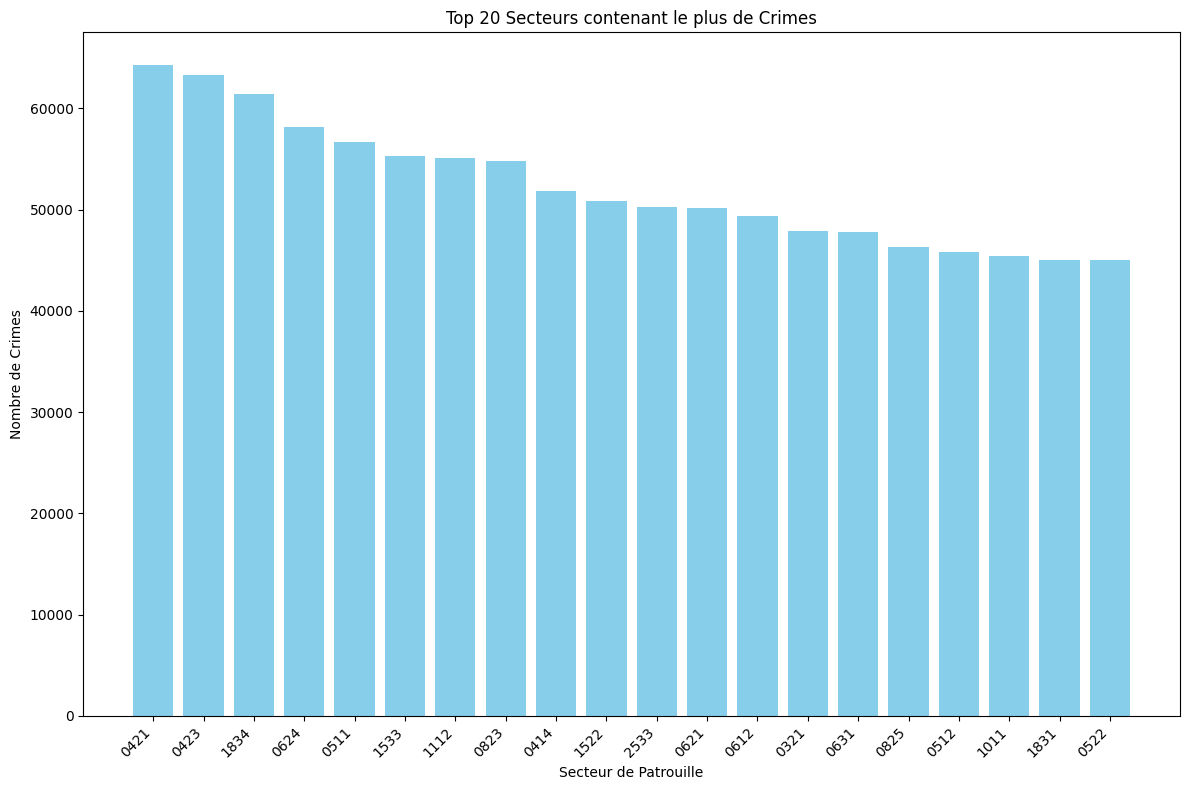

In [37]:
# Sélectionner les 20 premiers secteurs contenant le plus de crimes
top_20_crime_beats = crimes_by_beat_pd.head(20)

# Créer le graphique
plt.figure(figsize=(12, 8))
plt.bar(top_20_crime_beats['Beat'], top_20_crime_beats['count'], color='skyblue')
plt.xlabel('Secteur de Patrouille')
plt.ylabel('Nombre de Crimes')
plt.title('Top 20 Secteurs contenant le plus de Crimes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Enregistrer le graphique au format PNG
plt.savefig('9_top_20_crime_beats.png', format='png')

# Afficher le graphique
plt.show()

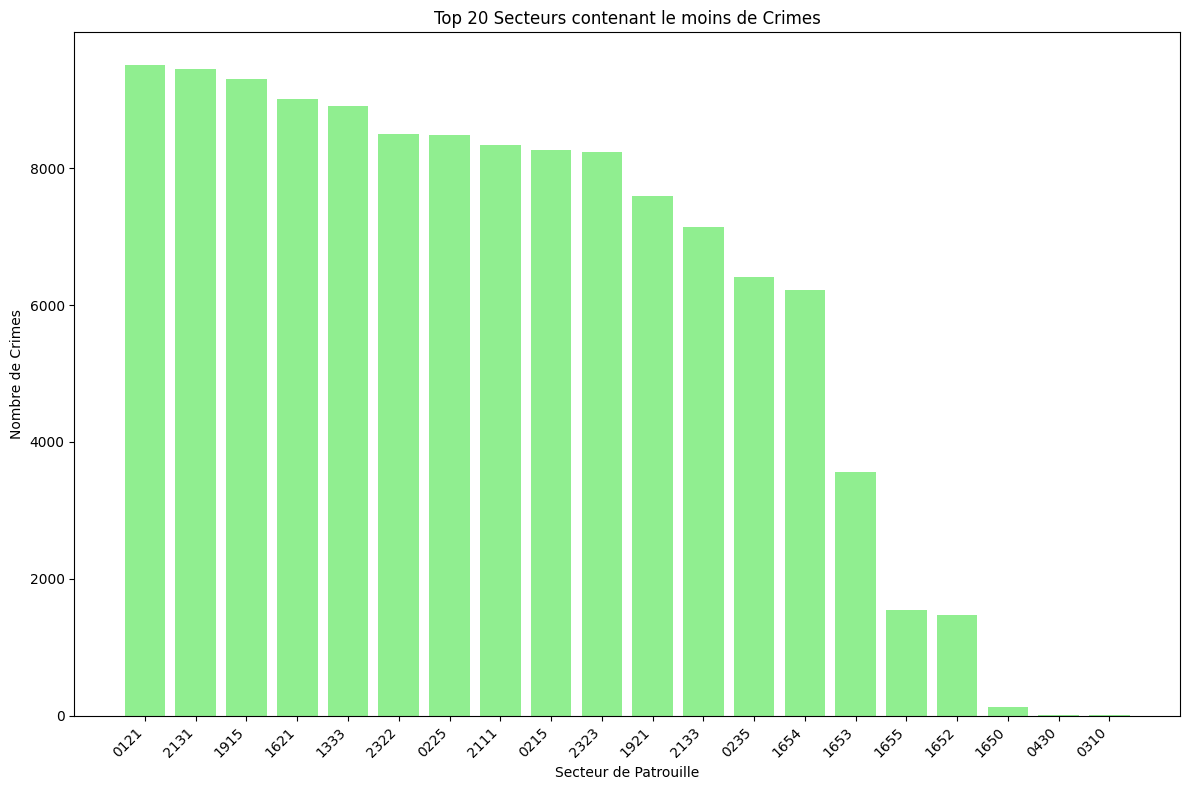

In [38]:
# Sélectionner les 20 premiers secteurs contenant le moins de crimes
bottom_20_crime_beats = crimes_by_beat_pd.tail(20)

# Créer le graphique
plt.figure(figsize=(12, 8))
plt.bar(bottom_20_crime_beats['Beat'], bottom_20_crime_beats['count'], color='lightgreen')
plt.xlabel('Secteur de Patrouille')
plt.ylabel('Nombre de Crimes')
plt.title('Top 20 Secteurs contenant le moins de Crimes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Enregistrer le graphique au format PNG
plt.savefig('10_bottom_20_crime_beats.png', format='png')

# Afficher le graphique
plt.show()

In [39]:
# Recommander des patrouilles en fonction des crimes par secteur
# Exemple simple de recommandation : augmenter les patrouilles dans les 10 secteurs avec le plus de crimes
top_10_beats = crimes_by_beat_pd.head(10)
print("Recommander des patrouilles supplémentaires dans les secteurs suivants :")
print(top_10_beats)

Recommander des patrouilles supplémentaires dans les secteurs suivants :
   Beat  count
0  0421  64293
1  0423  63266
2  1834  61460
3  0624  58118
4  0511  56630
5  1533  55291
6  1112  55114
7  0823  54819
8  0414  51808
9  1522  50846
